In [40]:
import pandas as pd

In [41]:
poly_events = pd.read_csv('data/events/poly_events.csv')
kalshi_events = pd.read_csv('data/events/kalshi_events.csv')

In [42]:
def map_poly_to_kalshi_tags(poly_tags_string):
    """
    Maps a comma-separated string of Polymarket tags to the 
    closest Kalshi category.
    """
    if pd.isna(poly_tags_string):
        return "other"
    
    tags = poly_tags_string.lower()
    
    # Define the mapping logic (Order matters: put specific terms first)
    mapping = {
        'crypto': ['crypto', 'bitcoin', 'ethereum', 'solana', 'airdrop', 'pre-market'],
        'politics': ['politics', 'election', 'senate', 'house', 'governor', 'midterms', 'trump', 'starmer'],
        'economics': ['finance', 'economy', 'business', 'gdp', 'fed rates', 'inflation', 'economic policy'],
        'sports': ['sports', 'nba', 'soccer', 'nhl', 'football', 'fifa', 'champions league', 'baseball'],
        'science and technology': ['tech', 'ai', 'openai', 'spacex', 'apple', 'big tech', 'sam altman'],
        'world': ['geopolitics', 'ukraine', 'russia', 'china', 'middle east', 'israel', 'world affairs'],
        'climate and weather': ['climate', 'weather', 'temp', 'global temp'],
        'entertainment': ['culture', 'movies', 'music', 'celebrities', 'taylor swift', 'gta vi'],
        'companies': ['ipo', 'ipos', 'stocks', 'acquisitions']
    }
    
    # Search the poly_tags_string for any of the keywords
    for kalshi_cat, keywords in mapping.items():
        if any(word in tags for word in keywords):
            return kalshi_cat
            
    return "social" # Default fallback

In [43]:
poly_events['tags'] = poly_events['tags'].apply(map_poly_to_kalshi_tags)

In [44]:
common_cols = kalshi_events.columns.intersection(poly_events.columns)
print(f'--- Common Cols: {len(common_cols)} ---')

kalshi_df_sync = kalshi_events[common_cols]
poly_df_sync = poly_events[common_cols]

print(f'--- Kalshi Shape: {kalshi_df_sync.shape} ---')
display(kalshi_df_sync.head())

print(f'\n--- PolyMarket Shape: {poly_df_sync.shape} ---')
poly_df_sync.head()

--- Common Cols: 4 ---
--- Kalshi Shape: (2514, 4) ---


,event_id,tags,event_title,platform
0,KXELONMARS-99,world,elon musk visit mars in his lifetime,kalshi
1,KXNEWPOPE-70,elections,the next pope be,kalshi
2,KXWARMING-50,climate and weather,world pass 2 degrees celsius over pre industri...,kalshi
3,KXMARSVRAIL-50,science and technology,human land on mars before california starts hi...,kalshi
4,KXERUPTSUPER-0,climate and weather,supervolcano erupt before 2050,kalshi



--- PolyMarket Shape: (4500, 4) ---


,event_id,tags,event_title,platform
0,100079,economics,paramount close warner bros acquisition by end...,poly
1,100229,politics,close warner bros acquisition,poly
2,100252,sports,merab dvalishivili fight next,poly
3,100253,crypto,tabi fdv above one day after launch,poly
4,100260,sports,petr yan fight next,poly


In [45]:
keyword_df = pd.read_csv('data/keywords.csv')
keyword_df['category'].unique()

<StringArray>
[   'person',   'company', 'geography',    'crypto',     'month', 'political',
      'econ',     'sport',      'misc']
Length: 9, dtype: str

In [46]:
import re
import pandas as pd

flattened_anchors = set()
for kw in keyword_df['keyword'].dropna().unique():
    # Split multi-word keywords and add each word to the set
    words = str(kw).lower().split()
    flattened_anchors.update(words)


def create_match_key(title, event_id):
    """
    Creates a dynamic key that handles multi-word entities by 
    deconstructing them into individual anchor tokens.
    """
    text = str(title).lower()
    
    # 1. THE WHEN: Extract Year
    year_match = re.search(r'20\d{2}', text)
    if year_match:
        year = year_match.group(0)
    else:
        id_year = re.search(r'-(\d{2})', str(event_id))
        year = f"20{id_year.group(1)}" if id_year else "9999"

    # 2. Clean text and tokenize
    clean_text = re.sub(r'[^a-z0-9\s]', '', text)
    tokens = set(clean_text.split()) # Use a set for faster intersection
    
    # 3. THE ANCHORS: Match tokens against the flattened list
    found_elements = list(tokens & flattened_anchors)
    
    # 4. Build the Composite Key
    if not found_elements:
        return f"unknown_{year}"
    
    # Sort ensure consistency regardless of word order in title
    found_elements.sort()
    entity_string = "_".join(found_elements)
    
    return f"{entity_string}_{year}"

# 5. Apply to your DataFrames
kalshi_events['match_key'] = kalshi_events.apply(lambda x: create_match_key(x['event_title'], x['event_id']), axis=1)
poly_events['match_key'] = poly_events.apply(lambda x: create_match_key(x['event_title'], x['event_id']), axis=1)

In [47]:
# kalshi_events
poly_events

,event_id,event_title,description,start_date,tags,platform,match_key
0,100079,paramount close warner bros acquisition by end...,this market will resolve to yes if paramount d...,NaN,economics,poly,unknown_2026
1,100229,close warner bros acquisition,this market will resolve according to the firs...,NaN,politics,poly,unknown_9999
2,100252,merab dvalishivili fight next,this market will resolve according to the next...,NaN,sports,poly,next_9999
3,100253,tabi fdv above one day after launch,this market will resolve to yes if the fully d...,NaN,crypto,poly,one_9999
4,100260,petr yan fight next,this market will resolve according to the next...,NaN,sports,poly,next_petr_yan_9999
...,...,...,...,...,...,...,...
4495,99573,netanyahu visit nyc by march 31,if israeli prime minister benjamin netanyahu v...,NaN,politics,poly,march_netanyahu_9999
4496,99578,netanyahu arrested by march 31,this market will resolve to yes if israeli pri...,NaN,politics,poly,march_netanyahu_9999
4497,99600,eu dissolves before 2027,this market will resolve to yes if the europea...,NaN,politics,poly,unknown_2027
4498,99601,any country withdraws from eu before 2027,this market will resolve to yes if any europea...,NaN,politics,poly,unknown_2027


In [48]:
kalshi_events

,series_id,event_id,tags,event_title,event_sub_title,platform,match_key
0,KXELONMARS,KXELONMARS-99,world,elon musk visit mars in his lifetime,before 2099,kalshi,elon_musk_2099
1,KXNEWPOPE,KXNEWPOPE-70,elections,the next pope be,before 2070,kalshi,next_pope_2070
2,KXWARMING,KXWARMING-50,climate and weather,world pass 2 degrees celsius over pre industri...,before 2050,kalshi,industrial_2050
3,KXMARSVRAIL,KXMARSVRAIL-50,science and technology,human land on mars before california starts hi...,before 2050,kalshi,california_2050
4,KXERUPTSUPER,KXERUPTSUPER-0,climate and weather,supervolcano erupt before 2050,a supervolcano,kalshi,unknown_2050
...,...,...,...,...,...,...,...
2509,KXFIGHTMENTION,KXFIGHTMENTION-26MAR28CHIPRI,mentions,announcers at chiesa vs price,chiesa vs price,kalshi,chiesa_2026
2510,KXFIGHTMENTION,KXFIGHTMENTION-26MAR28GRABAR,mentions,announcers at grasso vs barber,grasso vs barber,kalshi,unknown_2026
2511,KXPGAH2H,KXPGAH2H-MAST26SSCHRMCI,sports,full tournament head to head scheffler vs mcilroy,scheffler vs mcilroy,kalshi,head_9999
2512,KXFIGHTMENTION,KXFIGHTMENTION-26MAR28ADEPYF,mentions,announcers at adesanya vs pyfer,adesanya vs pyfer,kalshi,unknown_2026


In [49]:
from sentence_transformers import SentenceTransformer, util
from thefuzz import fuzz

# Load once to save memory
model = SentenceTransformer('all-MiniLM-L6-v2')

def get_market_matches(df_kalshi, df_poly, threshold=0.65):
    """
    Ranks Polymarket events against Kalshi events using a 
    Hard Match Key gate and Semantic Similarity.
    """
    all_results = []
    
    # 1. Identify common keys (e.g., 'trump_2026', 'bitcoin_2026')
    # This acts as our primary "Blocking" strategy
    common_keys = set(df_kalshi['match_key']) & set(df_poly['match_key'])
    
    for key in common_keys:
        # 2. Filter subsets by the specific match_key
        k_subset = df_kalshi[df_kalshi['match_key'] == key].reset_index(drop=True)
        p_subset = df_poly[df_poly['match_key'] == key].reset_index(drop=True)
        
        if k_subset.empty or p_subset.empty:
            continue
            
        # 3. Encode titles within this specific key-block
        k_titles = k_subset['event_title'].tolist()
        p_titles = p_subset['event_title'].tolist()
        
        k_embeddings = model.encode(k_titles, convert_to_tensor=True)
        p_embeddings = model.encode(p_titles, convert_to_tensor=True)

        # 4. Compute Semantic Similarity
        cosine_scores = util.cos_sim(k_embeddings, p_embeddings)

        # 5. Extract results
        for i, k_title in enumerate(k_titles):
            best_match_idx = cosine_scores[i].argmax().item()
            semantic_score = cosine_scores[i][best_match_idx].item()
            
            p_match_title = p_titles[best_match_idx]

            if semantic_score >= threshold:
                # 6. Calculate an additional 'Key Similarity' 
                # This double-checks that the specific names/entities align
                key_sim = fuzz.token_sort_ratio(k_title, p_match_title) / 100.0
                
                all_results.append({
                    'kalshi_key': k_subset.iloc[i]['match_key'],
                    'poly_key': p_subset.iloc[best_match_idx]['match_key'],
                    'tag': k_subset.iloc[i]['tags'],
                    'kalshi_title': k_title,
                    'poly_match': p_match_title,
                    'semantic_score': round(semantic_score, 4),
                    'key_sim_score': round(key_sim, 4),
                    'total_score': round((semantic_score + key_sim) / 2, 4),
                    'kalshi_id': k_subset.iloc[i]['event_id'],
                    'poly_id': p_subset.iloc[best_match_idx]['event_id']
                })

    if not all_results:
        return pd.DataFrame()
        
    # Return sorted by the combined total score
    return pd.DataFrame(all_results).sort_values(by='total_score', ascending=False).reset_index(drop=True)
# 5. Run the model
match_df = get_market_matches(kalshi_events, poly_events)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4966.07it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Current processor is good, but need to find a way to auto find key words so we dont have to hard code them

could use google trends to find unique words, as this would influnce the markets

array([[<Axes: title={'center': 'total_score'}>]], dtype=object)

count    56.000000
mean      0.765879
std       0.114156
min       0.554200
25%       0.684450
50%       0.755900
75%       0.819650
max       1.000000
Name: total_score, dtype: float64

,kalshi_key,poly_key,tag,kalshi_title,poly_match,semantic_score,key_sim_score,total_score,kalshi_id,poly_id
0,eurovision_2026,eurovision_2026,entertainment,eurovision winner 2026,eurovision winner 2026,1.0000,1.00,1.0000,KXEUROVISION-26,98369
1,iran_2026,iran_2026,companies,reza pahlavi lead iran in 2026,reza pahlavi lead iran in 2026,1.0000,1.00,1.0000,KXPAHLAVIHEAD-27JAN,238279
2,wave_2026,wave_2026,politics,blue wave in 2026,blue wave in 2026,1.0000,1.00,1.0000,KXBLUEWAVECOMBO-27FEB,103161
3,fed_9999,fed_9999,politics,be confirmed as fed chair,be confirmed as fed chair,1.0000,1.00,1.0000,KXFEDCHAIRCONFIRM,246219
4,unknown_9999,unknown_9999,politics,scotus bar counting mail ballots after electio...,scotus bars counting mail ballots after electi...,0.9756,0.99,0.9828,KXWATSONRNC,304787
5,democratic_2026,democratic_2026,elections,win the 2026 dc democratic mayoral primary,win the 2026 democratic d c mayoral primary,0.9345,0.96,0.9472,KXDCMAYORD-26,90292
6,justin_trudeau_2026,justin_trudeau_2026,entertainment,katy perry and justin trudeau be engaged in 2026,katy perry and justin trudeau engaged by end o...,0.9742,0.90,0.9371,KXENGAGEMENTTRUDEAUPERRY-26,97681
7,unknown_2026,unknown_2026,health,measles cases in 2026,measles cases in u s in 2026,0.9725,0.86,0.9163,KXMEASLES-26,91942
8,brazil_gdp_2026,brazil_gdp_2026,economics,brazil gdp growth in q4 2026 yoy,brazil gdp growth in q1 2026,0.9286,0.90,0.9143,KXBRAZILGDP-27FEB,246674
9,houston_texas_9999,houston_texas_9999,sports,texas children s houston open winner,pga tour texas children s houston open winner,0.9034,0.89,0.8967,KXPGATOUR-TECHO26,300296


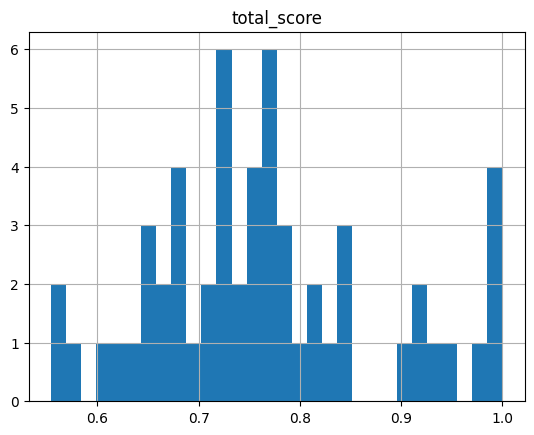

In [50]:
display(match_df.hist(column='total_score', bins=30))
display(match_df['total_score'].describe())

match_df[match_df['total_score'] > 0.6]
# match_df.to_csv('data/arb_candidates.csv', index=False)

In [51]:
match_df
unknown_check = match_df[match_df['kalshi_key'].str.contains('unknown', case=False, na=False)].reset_index(drop=True)
unknown_check.shape


(7, 10)

In [52]:
print(f'kalshi shape: {kalshi_events.shape}')
print(f'poly shape: {kalshi_events.shape}')

print(f'matches shape: {match_df.shape}')

threshhold = 0.8
print(f'matches > {threshhold} shape: {match_df[match_df['total_score'] > 0.8].shape}')

kalshi shape: (2514, 7)
poly shape: (2514, 7)
matches shape: (56, 10)
matches > 0.8 shape: (17, 10)
